In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


**Dataset Download**

During the project, I experienced issues with downloading the dataset manually from the Kaggle webpage — the file downloaded incompletely.
Because of that, I recommend using the Kaggle API, which turned out to be the most reliable method.

To download the dataset programmatically, upload your own kaggle.json authentication file by running the following code:

In [2]:
from google.colab import files
files.upload()

#Upload authentication kaggle.json file

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

from kaggle.api.kaggle_api_extended import KaggleApi
api = KaggleApi()
api.authenticate()

!kaggle datasets download -d austinreese/craigslist-carstrucks-data
!unzip craigslist-carstrucks-data.zip



Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/austinreese/craigslist-carstrucks-data
License(s): CC0-1.0
100% 262M/262M [00:04<00:00, 59.5MB/s]

Archive:  craigslist-carstrucks-data.zip
  inflating: vehicles.csv            


In [3]:
#Raw dataset
cars_raw = pd.read_csv('vehicles.csv')


Reading values in non-scientific notation for comfort


In [4]:
mpl.rcParams['axes.formatter.useoffset'] = False
mpl.rcParams['axes.formatter.use_mathtext'] = False
mpl.rcParams['axes.formatter.limits'] = (-10, 10)

In [5]:
pd.set_option('display.float_format', '{:.2f}'.format)


Raw data exploration


In [41]:
cars_raw.info()
cars_raw.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

(426880, 26)

In [7]:
cars_raw.isna().mean().sort_values(ascending=False)


,0
county,1.00
size,0.72
cylinders,0.42
condition,0.41
VIN,0.38
drive,0.31
paint_color,0.31
type,0.22
manufacturer,0.04
title_status,0.02


In [8]:
cars_raw.describe()

,id,price,year,odometer,county,lat,long
count,426880.00,426880.00,425675.00,422480.00,0.00,420331.00,420331.00
mean,7311486634.22,75199.03,2011.24,98043.33,NaN,38.49,-94.75
std,4473170.41,12182282.17,9.45,213881.50,NaN,5.84,18.37
min,7207408119.00,0.00,1900.00,0.00,NaN,-84.12,-159.83
25%,7308143339.25,5900.00,2008.00,37704.00,NaN,34.60,-111.94
50%,7312620821.00,13950.00,2013.00,85548.00,NaN,39.15,-88.43
75%,7315253543.50,26485.75,2017.00,133542.50,NaN,42.40,-80.83
max,7317101084.00,3736928711.00,2022.00,10000000.00,NaN,82.39,173.89


Histograms of numeric values in raw dataset

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'year'}>],
       [<Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'county'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>, <Axes: >, <Axes: >]],
      dtype=object)

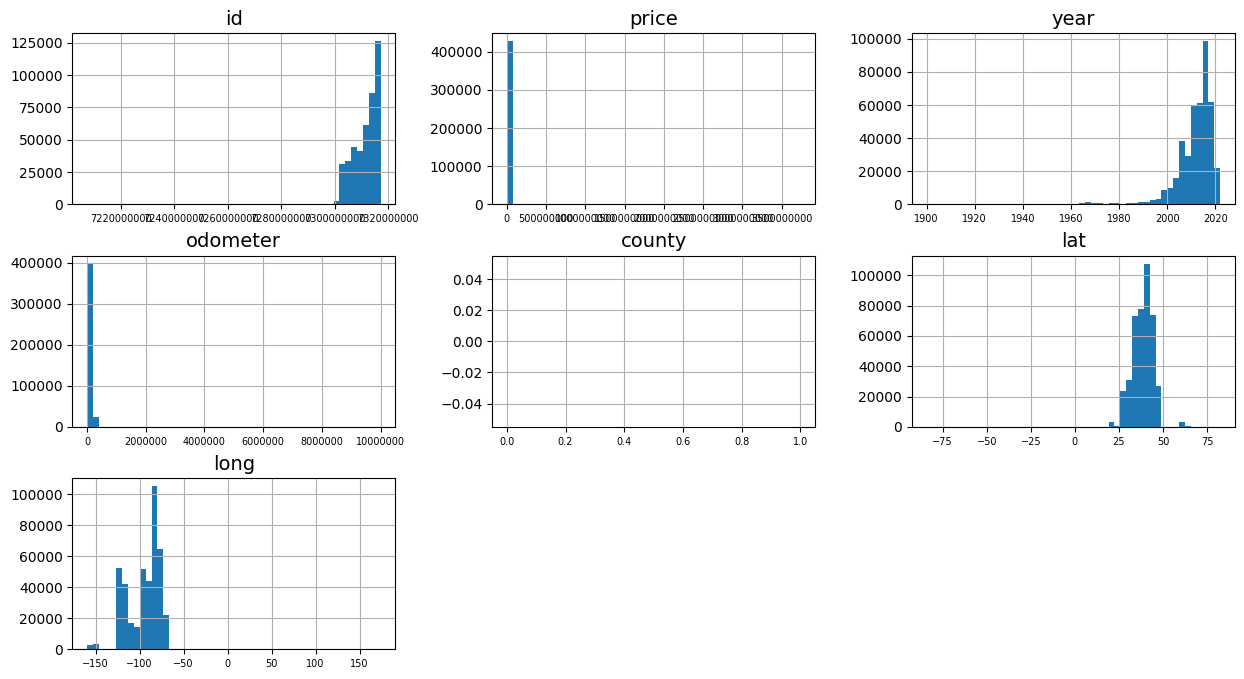

In [9]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=10)

cars_raw.hist(bins=50, figsize=(15, 8))

Initiall cleaning of the data. Includes removing outliers

In [42]:
cars_clean = cars_raw.copy()

In [43]:
cars_clean = cars_clean.query("price != 0")

In [44]:
#I made a decision to cope with outliers in target feature using the 95 quantile
q1 = cars_clean['price'].quantile(0.25)
q3 = cars_clean['price'].quantile(0.75)
q95 = cars_clean['price'].quantile(0.95)

med = cars_clean['price'].median()
[q1, q95, med]


[np.float64(7000.0), np.float64(44999.0), 15000.0]

In [45]:
#Checking if i don't miss a lot of data choosing 95's quantile as max value of target feature
(cars_clean['price'] > q95).mean() * 100

np.float64(4.996129294262472)

In [46]:
cars_clean = cars_clean.drop(columns=['url', 'region_url', 'image_url',
          'description','county','size', 'posting_date', 'id',
          'VIN', 'paint_color', 'region','state',
          'title_status'])


cars_clean = (
    cars_clean
    .query("price >= 1000")
    .query("24 < lat < 50 and -125 < long < -66")
    .query("year >= 2000")
)

q95 = cars_clean['price'].quantile(0.95)
cars_clean = (
    cars_clean
    .query("price <= @q95")
    .query("odometer <= 400000")
)

obj_cols = cars_clean.select_dtypes(include='object').columns

for col in obj_cols:
    cars_clean[col] = (
        cars_clean[col]
        .str.lower()
        .str.strip()
        .str.replace(r'\s+', ' ', regex=True)
        .str.replace(r'[^a-z0-9 ]', '', regex=True)
    )

cars_clean['cylinders_num'] = cars_clean['cylinders'].str.extract('(\d+)').astype('float')
cars_clean = cars_clean.drop(columns=['cylinders'])


In [47]:
cat_columms = cars_clean.select_dtypes(include='object').columns
for col in cat_columms:
    print('\n', col.upper())
    print(cars_clean[col].value_counts())


 MANUFACTURER
manufacturer
ford              52110
chevrolet         39840
toyota            27662
honda             18152
nissan            15733
jeep              14342
ram               12643
gmc               12075
bmw               11643
dodge             10301
hyundai            8786
subaru             8367
mercedesbenz       7959
volkswagen         7704
kia                6889
lexus              6882
audi               6359
cadillac           5429
acura              5354
chrysler           5123
mazda              4580
buick              4554
infiniti           4265
lincoln            3576
mitsubishi         2820
volvo              2803
mini               2036
pontiac            1616
jaguar             1565
rover              1430
saturn              984
porsche             835
alfaromeo           788
mercury             775
fiat                683
tesla               653
harleydavidson      118
astonmartin           8
land rover            8
ferrari               3
morgan      

Histograms of cleaned data

array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'year'}>],
       [<Axes: title={'center': 'odometer'}>,
        <Axes: title={'center': 'lat'}>],
       [<Axes: title={'center': 'long'}>,
        <Axes: title={'center': 'cylinders_num'}>]], dtype=object)

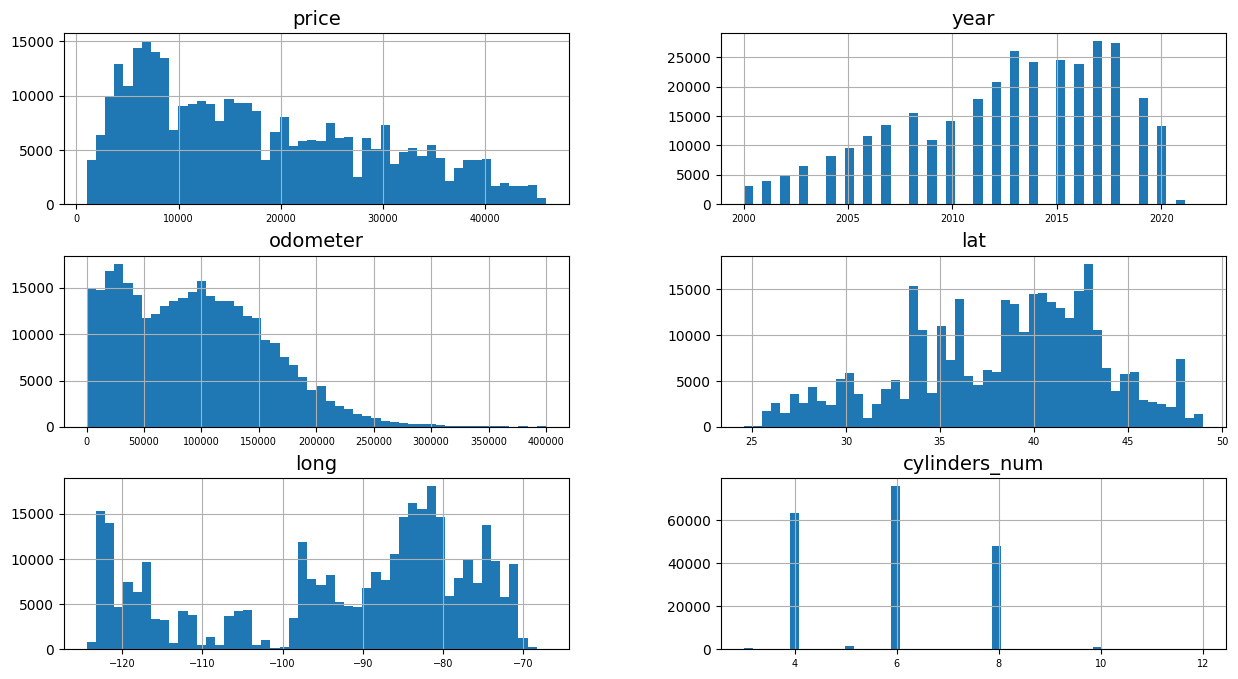

In [16]:
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=10)

cars_clean.hist(bins=50, figsize=(15, 8))

In [17]:
cars_clean.info()


<class 'pandas.core.frame.DataFrame'>
Index: 326832 entries, 27 to 426879
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   price          326832 non-null  int64  
 1   year           326832 non-null  float64
 2   manufacturer   317454 non-null  object 
 3   model          324410 non-null  object 
 4   condition      208356 non-null  object 
 5   fuel           324998 non-null  object 
 6   odometer       326832 non-null  float64
 7   transmission   325522 non-null  object 
 8   drive          226440 non-null  object 
 9   type           260290 non-null  object 
 10  lat            326832 non-null  float64
 11  long           326832 non-null  float64
 12  cylinders_num  190281 non-null  float64
dtypes: float64(5), int64(1), object(7)
memory usage: 34.9+ MB


Splitting the data function

In [4]:
from sklearn.model_selection import train_test_split
import hashlib

def hash_identifier(s):
      return hashlib.md5(s.encode('utf-8')).digest()[-1]

def hash_based_split(df, test_ratio=0.2):
    df = df.copy()

    df['id_hash'] = (
    df['manufacturer'].astype(str) + "_" +
    df['model'].astype(str) + "_" +
    df['year'].astype(str)
    )

    mask = df['id_hash'].apply(lambda x: hash_identifier(x) < 256 * test_ratio)

    train = df.loc[~mask].drop(columns=['id_hash'])
    test = df.loc[mask].drop(columns=['id_hash'])

    return train, test


def split_data(clean_data, split_method='random'):

  df = clean_data.copy()

  if split_method == 'random':

    cars_train, cars_test = train_test_split(
    df, test_size=0.2, random_state=42
    )

    return cars_train, cars_test

  elif split_method == 'stratified':

    df['log_price'] = np.log1p(df['price'])
    df['price_bin'] = pd.qcut(df['log_price'], 10, labels=False)

    cars_train, cars_test = train_test_split(
    df, test_size=0.2, stratify=df['price_bin'], random_state=42
    )

    cars_train = cars_train.drop(columns=['log_price', 'price_bin'])
    cars_test = cars_test.drop(columns=['log_price', 'price_bin'])

    return cars_train, cars_test

  elif split_method == 'hash':

    return hash_based_split(df)

  else:
    raise ValueError("split_method must be 'random', 'stratified', or 'hash'")


In [ ]:
cars_train, cars_test = split_data(cars_clean, split_method='stratified')

EDA on train set

<Axes: xlabel='long', ylabel='lat'>

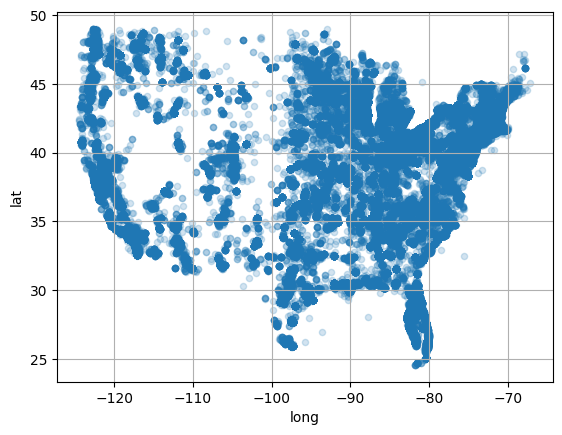

In [16]:
cars_train.plot(kind='scatter', x='long', y='lat', alpha=0.2, grid=True)

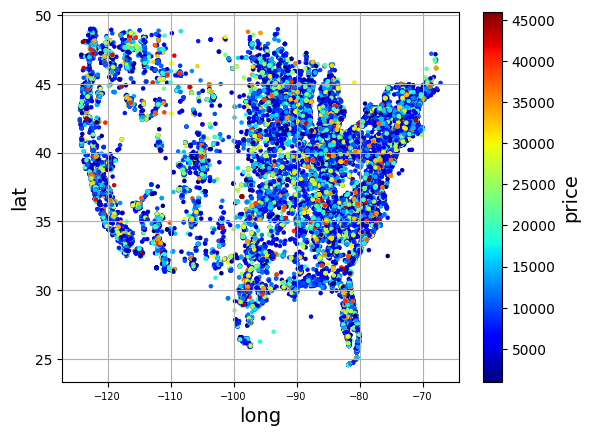

In [21]:
cars_train.plot(kind='scatter', x='long', y='lat', c='price', cmap='jet', s=5,
          colorbar=True, grid=True)
plt.show()

In [22]:
corr_matrix = cars_train.corr(numeric_only=True)
corr_matrix['price'].sort_values(ascending=False)

,price
price,1.00
year,0.65
cylinders_num,0.36
lat,-0.03
long,-0.04
odometer,-0.57


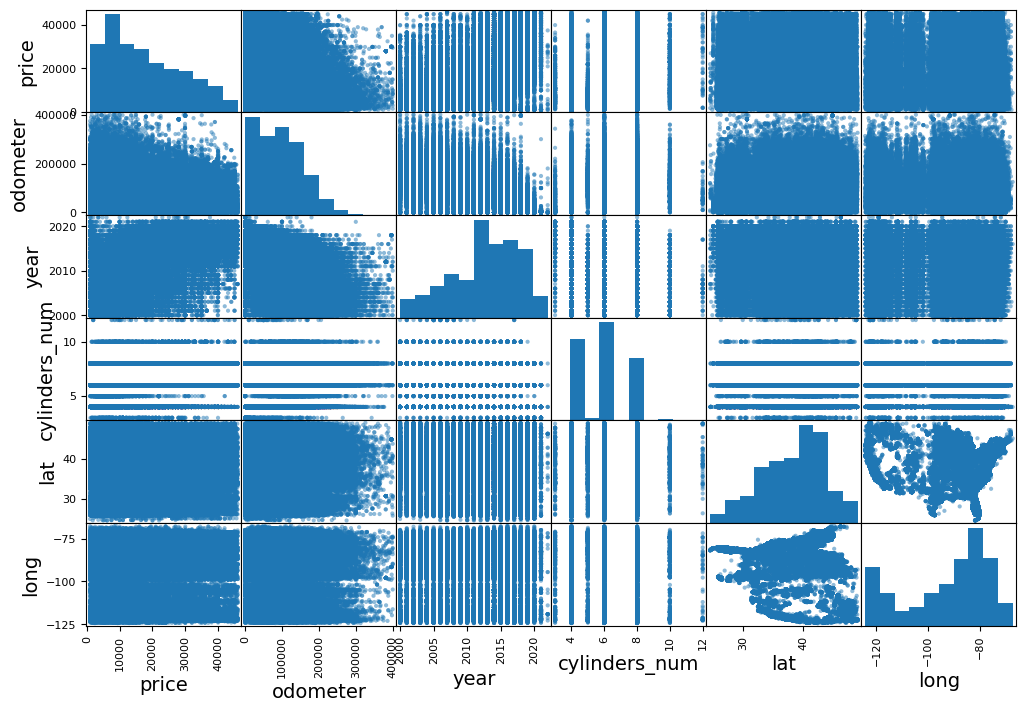

In [23]:
from pandas.plotting import scatter_matrix
attributes = ['price', 'odometer', 'year', 'cylinders_num', 'lat', 'long']
scatter_matrix(cars_train[attributes], figsize=(12, 8))
plt.show()

In [24]:
cars_train['year'] = cars_train['year'].astype(int)
cars_train['age'] = 2023 - cars_train['year']
cars_train['age'].corr(cars_train['price'])


np.float64(-0.6493277688561871)

In [25]:
from sklearn.cluster import KMeans

df = cars_train.copy()
mask = df[['lat', 'long']].notna().all(axis=1)
kmeans = KMeans(n_clusters=10, random_state=42)
df.loc[mask, 'reg_cluster'] = kmeans.fit_predict(df.loc[mask,['lat', 'long']])
df.groupby('reg_cluster')['price'].describe()


,count,mean,std,min,25%,50%,75%,max
reg_cluster,,,,,,,,
0.00,18136.00,17611.98,11299.23,1000.00,7991.00,15493.00,25990.00,45950.00
1.00,9822.00,20424.72,12006.87,1000.00,9995.00,18371.50,29998.00,45945.00
2.00,20406.00,19385.45,11791.40,1000.00,8888.25,17990.00,28900.00,45950.00
3.00,52131.00,16150.11,11234.15,1000.00,6700.00,12995.00,24590.00,45944.00
4.00,38844.00,16164.40,11379.75,1000.00,6500.00,12995.00,24775.00,45900.00
5.00,29962.00,16782.22,10455.19,1000.00,8000.00,14499.00,23995.00,45950.00
6.00,15132.00,19280.63,12062.87,1000.00,8995.00,16981.00,27999.00,45932.00
7.00,16308.00,18349.35,10897.83,1000.00,8995.00,16900.50,25999.00,45950.00
8.00,27136.00,17670.61,10995.59,1000.00,8200.00,15691.50,25700.00,45950.00


Final clean data function

In [5]:
def clean_data(data, remove_outliers=False):
  df = data.copy()
  df = (
    df
    .drop(columns=['url', 'region_url', 'image_url',
            'description','county','size', 'posting_date', 'id',
            'VIN', 'paint_color', 'region','state',
            'title_status', 'lat', 'long'])
    .query("price != 0")
    .query("price >= 1000")
    .query("year >= 2000")
  )

  df['cylinders_num'] = df['cylinders'].str.extract('(\d+)').astype('float')
  df['cylinder_missing'] = df['cylinders_num'].isna().astype(int)
  df = df.drop(columns=['cylinders'])

  if remove_outliers:
      q95 = df['price'].quantile(0.95)
      df = (
        df
        .query("price <= @q95")
        .query("odometer <= 400000")
        )

  obj_cols = df.select_dtypes(include='object').columns

  for col in obj_cols:

      df[col] = (
          df[col]
          .str.lower()
          .str.strip()
          .str.replace(r'\s+', ' ', regex=True)
          .str.replace(r'[^a-z0-9 ]', '', regex=True)
      )

  df['model'] = df['model'].fillna('missing')
  counts = df['manufacturer'].value_counts()
  rare = counts[counts < 50].index
  df['manufacturer'] = df['manufacturer'].replace(rare, 'rare')

  df = df.reset_index(drop=True)

  return df



Redefining clean data and splitting it


In [6]:
cars_clean = clean_data(cars_raw, remove_outliers=True)

In [7]:
strat_cars_train, strat_cars_test = split_data(cars_clean, split_method='stratified')

In [8]:
cars_train = strat_cars_train.drop(columns=['price'])
cars_train_labels = strat_cars_train['price'].copy()

Defining which features are in which category

In [9]:
text_feature = 'model'
log_features = ['odometer']
num_features_lin_regr = [col for col in cars_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
               if col not in log_features]
num_features = [col for col in cars_train.select_dtypes(include=['int64', 'float64']).columns.tolist()]
cat_features = [col for col in cars_train.select_dtypes(include=['object']).columns
                if col != text_feature]
catboost_cat_features = cat_features + ['model']
for col in cat_features:
    cars_train[col] = cars_train[col].fillna("missing").astype(str)



Transormers and preprocessing pipelines

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline


cat_transf = Pipeline([
        ('imputer', SimpleImputer(strategy="constant", fill_value="missing")),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

num_imputer = Pipeline([
        ('imputer', SimpleImputer(strategy="median"))
])

num_transf = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('scaler', StandardScaler())
])

log_transf = Pipeline([
        ('imputer', SimpleImputer(strategy="median")),
        ('log', FunctionTransformer(np.log1p)),
        ('scaler', StandardScaler())
])


lin_preprocess = ColumnTransformer(
    transformers=[
        ('num', num_transf, num_features_lin_regr),
        ('log', log_transf, log_features),
        ('cat', cat_transf, cat_features),
        ('text', TfidfVectorizer(max_features=5000), text_feature)
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', num_transf, num_features),
        ('cat', cat_transf, cat_features),
        ('text', TfidfVectorizer(max_features=5000), text_feature)
    ]
)


In [11]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


Defining all models and catboost cv function

In [12]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool, cv as catboost_cv_function

baseline = Pipeline([
    ('preprocess', preprocess),
    ('model', DummyRegressor(strategy='median'))
])

models = {
    'LinearRegression': Pipeline([
        ('preprocess', lin_preprocess),
        ('model', TransformedTargetRegressor(
            regressor=LinearRegression(),
            func=np.log1p,
            inverse_func=np.expm1))
    ]),

    'DecisionTree': Pipeline([
        ('preprocess', preprocess),
        ('model', TransformedTargetRegressor(
            regressor=DecisionTreeRegressor(
                random_state=42,
                max_depth=6,
                min_samples_leaf=5
            ),
            func=np.log1p,
            inverse_func=np.expm1))
    ]),

    'GradientBoosting': Pipeline([
        ('preprocess', preprocess),
        ('model', TransformedTargetRegressor(
            regressor=GradientBoostingRegressor(
                random_state=42,
                n_estimators=150,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8
            ),
            func=np.log1p,
            inverse_func=np.expm1))
    ]),

    'XGBoost': Pipeline([
        ('preprocess', preprocess),
        ('model', XGBRegressor(
                n_estimators=200,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="reg:squarederror",
                random_state=42
            ))
    ])
}

def catboost_cv(train_set, train_labels, cat_features):
    train_pool = Pool(
        data=train_set,
        label=train_labels,
        cat_features=cat_features
    )

    params = {
        "loss_function": "RMSE",
        "iterations": 500,
        "depth": 6,
        "learning_rate": 0.05,
        "random_seed": 42,
        "verbose": 0
    }

    cv_results = catboost_cv_function(
        params=params,
        pool=train_pool,
        fold_count=5,
        shuffle=True,
        partition_random_seed=42
    )

    mean_rmse = cv_results['test-RMSE-mean'].iloc[-1]
    std_rmse = cv_results['test-RMSE-std'].iloc[-1]

    return mean_rmse, std_rmse

Cross validation

In [13]:
from sklearn.model_selection import cross_val_score, KFold

folds = KFold(n_splits=5, shuffle=True, random_state=42)

baseline_scores = cross_val_score(baseline,
                                  cars_train,
                                  cars_train_labels,
                                  cv=5,
                                  scoring='neg_root_mean_squared_error',
                                  n_jobs=-1)

print(f"Baseline RMSE mean: {-baseline_scores.mean()}")

for name, model in models.items():
  scores = cross_val_score(
        model,
        cars_train,
        cars_train_labels,
        cv=folds,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
        )
  print(f"{name} RMSE mean ± std: {-scores.mean():.1f} ± {scores.std():.1f}")

cb_mean_rmse, cb_std = catboost_cv(
      cars_train, cars_train_labels,
      catboost_cat_features
)

print(f"Catboost RMSE mean ± std: {cb_mean_rmse:.1f} ± {cb_std:.1f} ")


Baseline RMSE mean: 11567.189916803927
LinearRegression RMSE mean ± std: 5018.7 ± 118.2
DecisionTree RMSE mean ± std: 6653.1 ± 33.5
GradientBoosting RMSE mean ± std: 5430.7 ± 24.3
XGBoost RMSE mean ± std: 4084.6 ± 34.5
Training on fold [0/5]

bestTest = 4020.988133
bestIteration = 499

Training on fold [1/5]

bestTest = 4050.117696
bestIteration = 499

Training on fold [2/5]

bestTest = 4035.026177
bestIteration = 499

Training on fold [3/5]

bestTest = 4037.65549
bestIteration = 499

Training on fold [4/5]

bestTest = 4028.307338
bestIteration = 499

Catboost RMSE mean ± std: 4034.4 ± 10.9 


Randomized search on Catboost and XGBoost models


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.base import BaseEstimator, RegressorMixin

xgb_pipeline = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBRegressor(random_state=42, objective='reg:squarederror'))
])

class CatBoostWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, cat_features, learning_rate=0.1, depth=6, iterations=500,
                 l2_leaf_reg=3, bagging_temperature=0.0):
        self.cat_features = cat_features
        self.learning_rate = learning_rate
        self.depth = depth
        self.iterations = iterations
        self.l2_leaf_reg = l2_leaf_reg
        self.bagging_temperature = bagging_temperature
        self.model = None

    def fit(self, X, y):
        train_pool = Pool(
            data=X,
            label=y,
            cat_features=self.cat_features
        )
        self.model = CatBoostRegressor(
            learning_rate=self.learning_rate,
            depth=self.depth,
            iterations=self.iterations,
            l2_leaf_reg=self.l2_leaf_reg,
            bagging_temperature=self.bagging_temperature,
            loss_function="RMSE",
            verbose=0,
            random_seed=42
        )
        self.model.fit(train_pool)
        return self

    def predict(self, X):
        test_pool = Pool(
            data=X,
            cat_features=self.cat_features
        )
        return self.model.predict(test_pool)

xgb_param_dist = {
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [4, 5, 6, 8],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__n_estimators': [300, 500, 700],
    'model__reg_alpha': [0, 0.1, 1],
    'model__reg_lambda': [1, 3, 5]
}

cat_param_dist = {
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'depth': [4, 6, 8],
    'iterations': [500, 700, 1000],
    'l2_leaf_reg': [1, 3, 5, 7],
    'bagging_temperature': [0, 0.5, 1]
}

xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    xgb_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

cat_search = RandomizedSearchCV(
    estimator=CatBoostWrapper(cat_features=catboost_cat_features),
    param_distributions=cat_param_dist,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)

cat_search.fit(cars_train, cars_train_labels)
xgb_search.fit(cars_train, cars_train_labels)

print("XGBoost best params:", xgb_search.best_params_)
print("XGBoost best RMSE:", -xgb_search.best_score_)
print("XGBoost RMSE std:", xgb_search.cv_results_["std_test_score"][xgb_search.best_index_])

print("CatBoost best params:", cat_search.best_params_)
print("CatBoost best RMSE:", -cat_search.best_score_)
print("CatBoost RMSE std:", cat_search.cv_results_["std_test_score"][cat_search.best_index_])


XGBoost best params: {'model__subsample': 0.8, 'model__reg_lambda': 5, 'model__reg_alpha': 1, 'model__n_estimators': 700, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.6}
XGBoost best RMSE: 3306.878466796875
XGBoost RMSE std: 22.380670335874953
CatBoost best params: {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 1000, 'depth': 8, 'bagging_temperature': 0.5}
CatBoost best RMSE: 3391.792431523239
CatBoost RMSE std: 23.257932915535303


In [14]:
from xgboost import XGBRegressor


best_model = Pipeline([
    ('preprocess', preprocess),
    ('model', XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            random_state=42
        ))
])


best_model.fit(cars_train, cars_train_labels)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'odometer',
                                                   'cylinders_num',
                                                   'cylinder_missing']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ign...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=6, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=300, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [ ]:
import joblib

os.makedirs("models", exist_ok=True)

best_model = xgb_search.best_estimator_
best_model.fit(cars_train, cars_train_labels)

joblib.dump(best_model, "models/xgb.pkl")


Assesing the model on test set

In [15]:
cars_test = strat_cars_test.drop(columns=['price'])
cars_test_labels = strat_cars_test['price'].copy()

from sklearn.metrics import mean_squared_error

preds = best_model.predict(cars_test)
rmse = np.sqrt(mean_squared_error(cars_test_labels, preds))
print(rmse)


4188.410915848634


Expirimenting with data with outliers

In [16]:
cars_clean_w_outliers = clean_data(cars_raw, remove_outliers=False)
strat_cars_train_w_outliers, strat_cars_test_w_outliers = split_data(cars_clean_w_outliers, split_method='stratified')

cars_test_w_outliers = strat_cars_test_w_outliers.drop(columns=['price'])
cars_test_labels_w_outliers = strat_cars_test_w_outliers['price'].copy()

preds_w_outliers = best_model.predict(cars_test_w_outliers)
rmse_w_outliers = np.sqrt(mean_squared_error(cars_test_labels_w_outliers, preds_w_outliers))
print(rmse_w_outliers)


11362259.702869672


Expirimenting with random split

In [17]:
cars_clean2 = clean_data(cars_raw, remove_outliers=True)
strat_cars_train2, strat_cars_test2 = split_data(cars_clean2, split_method='random')

cars_test2 = strat_cars_test2.drop(columns=['price'])
cars_test_labels2 = strat_cars_test2['price'].copy()

preds2 = best_model.predict(cars_test2)
rmse2 = np.sqrt(mean_squared_error(cars_test_labels2, preds2))
print(rmse2)


4145.031966101106


Feature importances

In [18]:
xgb = best_model.named_steps['model']
importances = xgb.feature_importances_

feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

feature_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importances)

                      feature  importance
59    cat__transmission_other    0.055231
50           cat__fuel_diesel    0.029525
0                   num__year    0.024503
72           cat__type_pickup    0.018681
61             cat__drive_fwd    0.017248
...                       ...         ...
1828              text__doubl    0.000000
1827               text__doub    0.000000
1826                text__dou    0.000000
1825               text__dose    0.000000
1835           text__dragster    0.000000

[5078 rows x 2 columns]


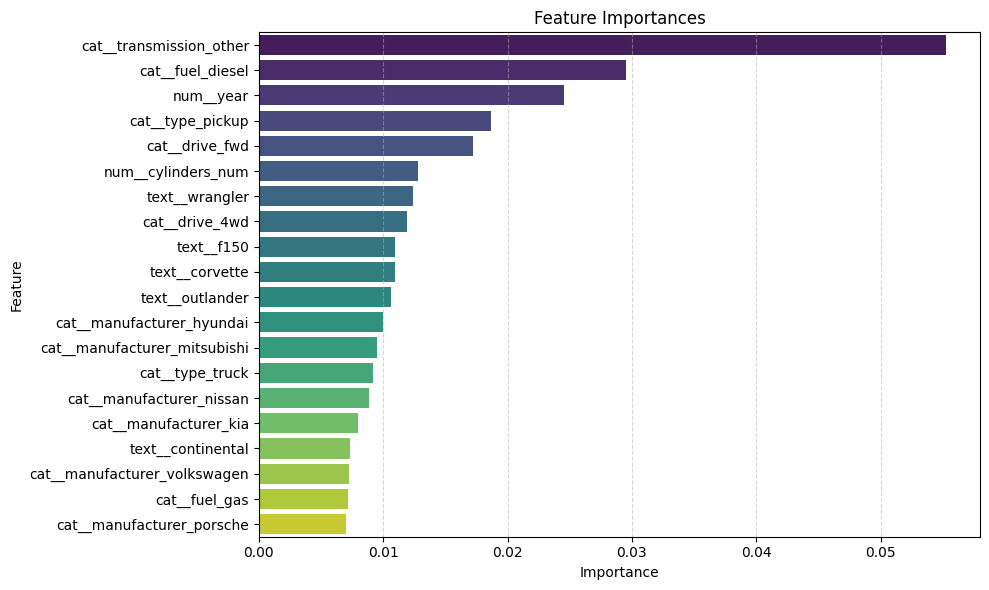

In [19]:
plt.figure(figsize=(10, 6))

sns.barplot(
      data=feature_importances.head(20),
      x='importance',
      y='feature',
      palette='viridis'
)

plt.title('Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

SHAP plot

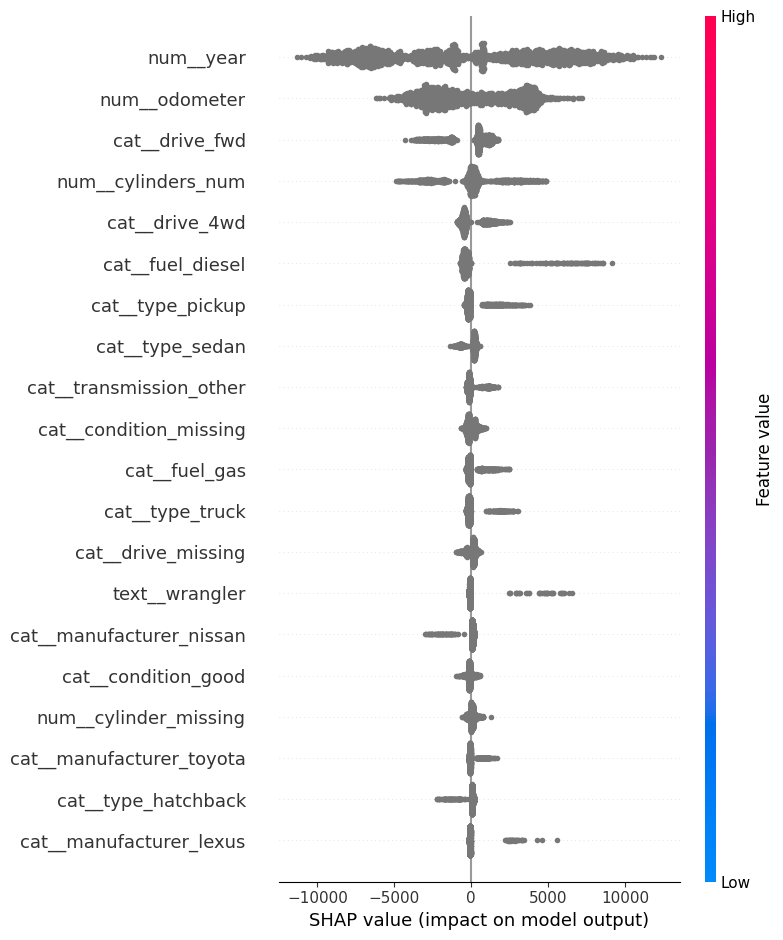

In [20]:
import shap

def plot_shap_summary(model_pipeline, X, sample_size=2000, max_display=20, random_state=42):
    X_sample = X.sample(sample_size, random_state=random_state)
    preprocess = model_pipeline.named_steps['preprocess']
    model = model_pipeline.named_steps['model']
    X_transformed = preprocess.transform(X_sample)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_transformed)
    shap.summary_plot(
        shap_values,
        X_transformed,
        feature_names=preprocess.get_feature_names_out(),
        max_display=max_display,
        show=True
    )

plot_shap_summary(best_model, cars_train, sample_size=2000, max_display=20)
